# Hybrid Rotator 90 Degree

Converts TE -> TM. The structure is a digital metamaterial mapped from bit array [0,1,0,1,1,0,1,...] into a 3D structure. In this array, '0' represents as air block and '1' represents as silicon block.

References: 
- [Base TE<->TM Polarization Rotator using Digital Metamaterial by Majumder](https://opg.optica.org/oe/fulltext.cfm?uri=oe-25-17-19721)
- [Inverse Design with AM-FEM (not FDTD but the adjoint method can be applied with optigrad tidy3d)](https://opg.optica.org/oe/fulltext.cfm?uri=oe-34-2-2047)

## Geometry Creation
create from defining the tech and ports. Then create the core rotator. After the core, create the top level circuit.

In [ ]:
import json
import struct
import numpy as np
import matplotlib.pyplot as plt
import photonforge as pf
import siepic_forge as siepic
import luxtelligence_lnoi400_forge as lxt
import tidy3d as td

td.config.logging.level = "ERROR"

# Set up technologies
siepic_tech = siepic.ebeam()
basic_tech = pf.basic_technology()
lxt_tech = lxt.lnoi400()
pf.config.default_technology = siepic_tech

# Initialize live viewer for real-time visualization
from photonforge.live_viewer import LiveViewer
viewer = LiveViewer()

# Define simulation parameters
# lower resolution for cheaper simulation. initially it was set at 101 now lower to 41
wavelengths = np.linspace(1.53, 1.57, 41)
freqs = pf.C_0 / wavelengths

LiveViewer started at http://localhost:55229


In [19]:
dual_mode_spec = siepic_tech.ports["TE_1550_500"].copy()
dual_mode_spec.num_modes = 2  # Use both modes

siepic_tech.add_port("TE-TM_1550_500", dual_mode_spec)
siepic_tech.ports["TE-TM_1550_500"]

PortSpec(description="Strip TE 1550 nm, w=500 nm", width=1.5, limits=(-0.6, 0.82), num_modes=2, added_solver_modes=0, polarization="", target_neff=3.5, default_radius=0, path_profiles=[(0.5, 0, (1, 0))])

In [20]:
# digital metamaterial based on 0 and 1, 0 is air, 1 is silicon

# max_pixels = total element in array
rot_length = 5.0
rot_width = 1.5
wg_resolution = 0.1
max_pixels = int(rot_length/wg_resolution) * int(rot_width/wg_resolution)
print(max_pixels)

# bit array covers the whole range with no numeric ceiling: all-air, all-silicon, or anything between
all_air = np.zeros(max_pixels, dtype=np.uint8)
all_silicon = np.ones(max_pixels, dtype=np.uint8)
random_pattern = np.random.default_rng(0).integers(0, 2, size=max_pixels, dtype=np.uint8)

# print the first 10 elements of each pattern for verification
print(all_air[:10], all_silicon[:10], random_pattern[:10])

750
[0 0 0 0 0 0 0 0 0 0] [1 1 1 1 1 1 1 1 1 1] [0 1 1 1 1 1 0 1 0 1]


In [21]:
# number to bit array conversion
def number_to_bits(n: int, num_bits: int) -> np.ndarray:
    bit_string = format(n, f'0{num_bits}b')  # MSB-first, zero-padded to num_bits
    return np.array(list(bit_string), dtype=np.uint8)

pattern = number_to_bits(123456789012345678901234567890, max_pixels)
print(pattern[:10])


# bit array to number conversion
def bits_to_number(bits: np.ndarray) -> int:
    bit_string = ''.join(bits.astype(str))
    return int(bit_string, 2)

n = bits_to_number(pattern)
print(n)

[0 0 0 0 0 0 0 0 0 0]
123456789012345678901234567890


In [34]:
# digital metamaterial based on 0 and 1, 0 is air, 1 is silicon
# max pixels = rot_length/wg_resolution * rot_width/wg_resolution = 5.0/0.1 * 1.5/0.1 = 750

@pf.parametric_component
def create_hybrid_rotator_90(*, bits, rot_length = 5.0, rot_width = 1.5, wg_resolution = 0.1):

    wg_height = 0.22
    max_pixels = int(rot_length/wg_resolution) * int(rot_width/wg_resolution)

    # a reminder to connect to the waveguides on the left and right sides of the component
    # i think we can simulate with what we have now
    #wg_length = 2.0
    #wg_width = 0.5

    bits = np.asarray(bits, dtype=np.uint8)
    if bits.shape != (max_pixels,):
        raise ValueError(f"bits must have shape ({max_pixels},), got {bits.shape}")

    # Create an empty component named "HybridRotator"
    hybrid_rotator_90 = pf.Component("HybridRotator90")

    # Create the digital metamaterial based on the bit array
    n = 0
    for i in range(int(rot_width/wg_resolution)):
        for j in range(int(rot_length/wg_resolution)):
            if bits[n]:
                # Create a silicon rectangle for each "1" pixel
                x = j * wg_resolution + wg_resolution/2 - rot_length/2
                y = rot_width/2 - wg_resolution/2 - i*wg_resolution
                silicon = pf.Rectangle(size=(wg_resolution, wg_resolution), center=(x, y))
                hybrid_rotator_90.add("Si", silicon)
            n += 1

    hybrid_rotator_90.add_port(
        pf.Port(center=(-rot_length/2, 0), input_direction=0, spec=siepic_tech.ports["TE_1550_500"])
    )

    hybrid_rotator_90.add_port(
        pf.Port(center=(rot_length/2, 0), input_direction=180, spec=siepic_tech.ports["TE-TM_1550_500"])
    )

    field_monitor = td.FieldMonitor(
        center=(0, 0, 0.11), size=(td.inf, td.inf, 0), freqs=[freqs.mean()], name="field"
    )

    input_monitor = td.FieldMonitor(
        center=[-rot_length/2, 0.0, wg_height / 2],
        size=[0.0, rot_width * 3, wg_height * 3],
        freqs=freqs,
        name="input",
        fields=["Ex", "Ey", "Ez", "Hx", "Hy", "Hz"]
    )

    output_monitor = td.FieldMonitor(
        center=[rot_length/2, 0.0, wg_height / 2],
        size=[0.0, rot_width * 3, wg_height * 3],
        freqs=freqs,
        name="output",
        fields=["Ex", "Ey", "Ez", "Hx", "Hy", "Hz"]
    )

    # Include the Tidy3D simulation model
    hybrid_rotator_90.add_model(pf.Tidy3DModel(monitors=[field_monitor, input_monitor, output_monitor]), "Tidy3DModel")
    return hybrid_rotator_90


# Instantiate the component with a bit array: length max_pixels, 0 = air, 1 = silicon.
# Covers the whole range with no numeric ceiling, e.g.:
#   np.zeros(max_pixels, dtype=np.uint8)                                    -> all air
#   np.ones(max_pixels, dtype=np.uint8)                                     -> all silicon
#   np.random.default_rng(seed).integers(0, 2, size=max_pixels, dtype=np.uint8) -> random pattern
rot_length, rot_width, wg_resolution = 5.0, 1.5, 0.1
max_pixels = int(rot_length/wg_resolution) * int(rot_width/wg_resolution)
bits = np.random.default_rng(0).integers(0, 2, size=max_pixels, dtype=np.uint8)

hybrid_rotator_90 = create_hybrid_rotator_90(bits=bits, rot_length=rot_length, rot_width=rot_width, wg_resolution=wg_resolution)
viewer(hybrid_rotator_90)

In [37]:
# REMINDER: To view the actual 3d structure, go to visibility -> structures -> then unsee structure_1

pf.tidy3d_plot(hybrid_rotator_90, plot_type="3d")

In [24]:
n = bits_to_number(bits)
print(n)

2903077976970071805342230547150527928031182210404388204938712757223316085135301030866034917955810872705958788835117362110056504052952848499838493929608989008368304918490396227937313994398795125963079987301232525352133440497577


In [ ]:
# Connect to short straight waveguide for top level simulation
@pf.parametric_component
def create_hybrid_rotator_90_with_wg(wg_length = 2.0, use_gc = False):

    #wg_height = 0.22

    hybrid_rotator_90_with_wg = pf.Component("hybrid_rotator_90_with_wg")

    half_straight1 = pf.parametric.straight(port_spec="TE_1550_500", length=wg_length)
    half_straight2 = pf.parametric.straight(port_spec="TE-TM_1550_500", length=wg_length)
    grating_coupler = siepic.component("ebeam_gc_te1550")
    hybrid_rotator_90 = create_hybrid_rotator_90(bits=bits, rot_length=rot_length, rot_width=rot_width, wg_resolution=wg_resolution)

    # add reference
    rot1_ref = hybrid_rotator_90_with_wg.add_reference(hybrid_rotator_90)
    hst1_ref = hybrid_rotator_90_with_wg.add_reference(half_straight1)
    hst2_ref = hybrid_rotator_90_with_wg.add_reference(half_straight2)

    # connect input waveguide to rotator, then connect output rotator to output waveguide
    # sesudah connect ke sebelum
    rot1_ref.connect("P0", hst1_ref["P1"])
    hst2_ref.connect("P0", rot1_ref["P1"])

    # Connect to gc by adding ref then connect to input of waveguide
    if use_gc:
        gc1_ref = hybrid_rotator_90_with_wg.add_reference(grating_coupler)
        hst1_ref.connect("P0", gc1_ref["P0"])

    '''
    idk kenapa posisinya portnya diluar bound simulation...
    field_monitor = td.FieldMonitor(
        center=(0, 0, 0.11), size=(td.inf, td.inf, 0), freqs=[freqs.mean()], name="field"
    )

    input_monitor = td.FieldMonitor(
        center=[(-rot_length)/2, 0.0, wg_height / 2],
        size=[0.0, rot_width * 3, wg_height * 3],
        freqs=freqs,
        name="input",
        fields=["Ex", "Ey", "Ez", "Hx", "Hy", "Hz"]
    )

    output_monitor = td.FieldMonitor(
        center=[(rot_length)/2, 0.0, wg_height / 2],
        size=[0.0, rot_width * 3, wg_height * 3],
        freqs=freqs,
        name="output",
        fields=["Ex", "Ey", "Ez", "Hx", "Hy", "Hz"]
    )
    '''

    # TOP LEVEL PORTS

    # auto assign port but this made the P1 also TE while we want the output has different port
    # hybrid_rotator_90_with_wg.add_port(hybrid_rotator_90_with_wg.detect_ports(["TE_1550_500"], on_boundary="x"))

    hybrid_rotator_90_with_wg.add_port(
        pf.Port(center=(0, 0), input_direction=0, spec=siepic_tech.ports["TE_1550_500"])
    )

    hybrid_rotator_90_with_wg.add_port(
        pf.Port(center=(rot_length + 2*wg_length, 0), input_direction=180, spec=siepic_tech.ports["TE-TM_1550_500"])
    )
    hybrid_rotator_90_with_wg.add_model(pf.Tidy3DModel(
        #monitors=[field_monitor, input_monitor, output_monitor]
        ), "Tidy3DModel")


    return hybrid_rotator_90_with_wg

rot_top = create_hybrid_rotator_90_with_wg(wg_length=2.0, use_gc=False)
viewer(rot_top)

In [58]:
# REMINDER: To view the actual 3d structure, go to visibility -> structures -> then unsee structure_1

pf.tidy3d_plot(rot_top, plot_type="3d")

In [ ]:
# cek mode solver buat pastiin kalo sinyal masuk keluar TE TM nya. Cek photonic crystal ada cara pake modesolver

In [ ]:
# janlup estimate cost simulation untuk geometri ini
# untuk 1.53 to 1.57 um dengan 41 points, estimasi flexcredit = 2.504 worst case, 0.779 actual simulation, lama simulasi = 2 menit

simulations = rot_top.active_model.get_simulations(rot_top, freqs)

# simulations.keys()
td.web.Batch(simulations=simulations).estimate_cost()

20:33:58 SE Asia Standard Time Maximum FlexCredit cost: 2.504 for the whole     
                               batch.

2.5037040109336774

Uploading task 'P0@0…'
Uploading task 'P1@0…'
Uploading task 'P1@1…'
Starting task 'P1@0': https://tidy3d.simulation.cloud/workbench?taskId=fdve-6817e7ab-a9a2-4095-bb66-8d3cb5881e37
Starting task 'P0@0': https://tidy3d.simulation.cloud/workbench?taskId=fdve-bb43b8ed-2030-4f3d-99e8-354c1d605954
Starting task 'P1@1': https://tidy3d.simulation.cloud/workbench?taskId=fdve-052cc944-386a-4b5c-9ff7-8c8914918544


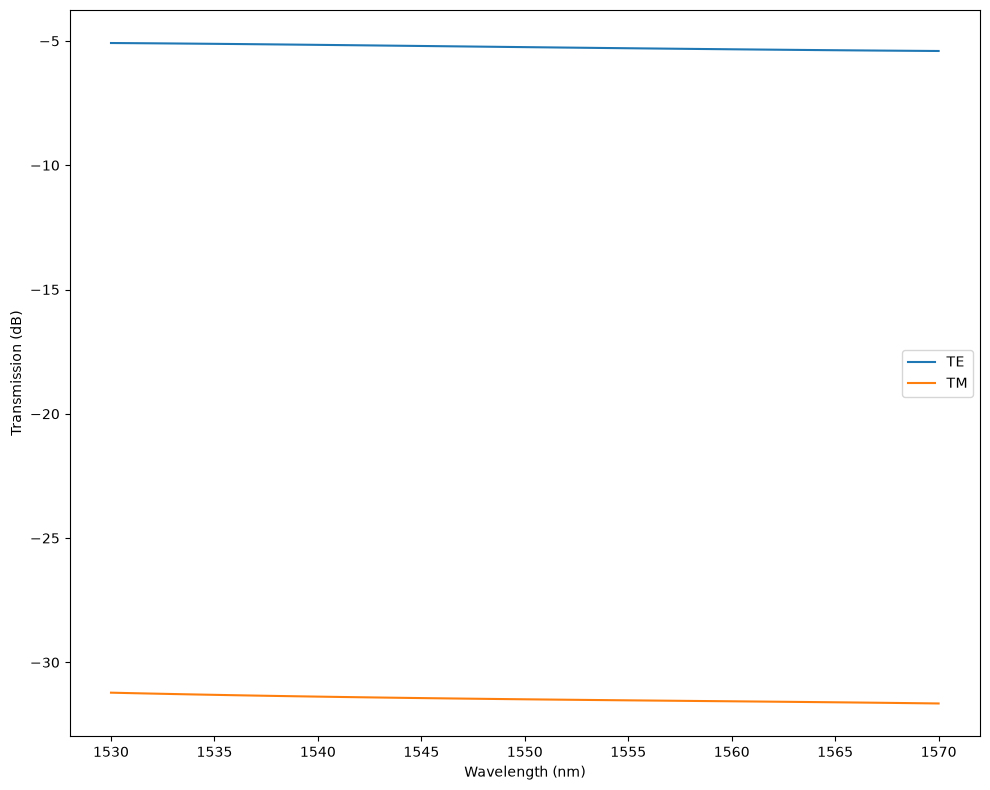

In [59]:
# Initial Simulation: Get TE TM transmission, also ER and field monitor

# make one figure/axes
fig, axs = plt.subplots(nrows=1, ncols=1, figsize=(10, 8))

s_matrix = rot_top.s_matrix(
    pf.C_0 / wavelengths, show_progress=False
)

# make sure ini ga kebalik TE-TM nya. cek pake mode solver
s0 = s_matrix[("P0@0", "P1@0")]
s1 = s_matrix[("P0@0", "P1@1")]
axs.plot(
    wavelengths * 1e3,
    10 * np.log10(np.abs(s0)),
    label=f"TE",
    linewidth=1.5,
)
axs.plot(
    wavelengths * 1e3,
    10 * np.log10(np.abs(s1)),
    label=f"TM",
    linewidth=1.5
)
axs.legend()
axs.set_xlabel("Wavelength (nm)")
axs.set_ylabel("Transmission (dB)")

plt.tight_layout()
plt.show()

## Inverse Design

We can test several different algorithms to find the most optimal design for the hybrid rotator. The goal is to maximize the extinction ratio (ER) while also maintaining manufacturability constraints. Some of the algorithms we can test include: [modified DBS](https://opg.optica.org/oe/fulltext.cfm?uri=oe-25-17-19721), Optuna, and [Bayesian Optimization](https://arxiv.org/abs/1807.02811), and many others. Keep in mind Tidy3d inverse design is expensive. Further exploration we can tune parameters such as the number of pixels, the resolution of the waveguide, and the length and width of the rotator. We can also explore different materials for the rotator, such as silicon nitride or silicon dioxide.

### Cost Estimation
According to Majumder, if we actually follow the same amount of iterations (50 iters), we will need 2 $\times$ 50 $\times$ 0.779 = **77.9 flexcredits**. Optigrad uses 2 FDTD simulation per iteration. Max per batch of single s-matrix simulation of this device is 2.504. This is a lot of flexcredits, so we will need to be careful with our simulations. We can also try to reduce the number of iterations by using a more efficient algorithm.

In [ ]:
# Inverse Design: Get the highest possible ER while also maintaining manufacturability constraints.